In [40]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt

In [41]:
#Data (We use log returns)
data = yf.download('SPY', start='2005-01-01', end='2025-01-01', auto_adjust=True)
close = data['Close'].squeeze()
returns = np.log(close / close.shift(1)).dropna()

rolling_vol = returns.rolling(20).std()

momentum = returns.rolling(10).mean()

#Rolling volatility (20 day window) + Momentum (10 day window)
features = pd.DataFrame({
    'returns': returns,
    'volatility': rolling_vol,
    'momentum': momentum
}).dropna()

print(f"Data loaded: {len(features)} trading days")
print(features.head())

[*********************100%***********************]  1 of 1 completed

Data loaded: 5013 trading days
             returns  volatility  momentum
Date                                      
2005-02-01  0.006327    0.006442 -0.000470
2005-02-02  0.003024    0.005860  0.000884
2005-02-03 -0.002603    0.005660  0.001235
2005-02-04  0.010620    0.006025  0.002911
2005-02-07 -0.001332    0.006024  0.002975


In [42]:
split = int(len(features) * 0.8)

#iloc = integer locate
train_features = features.iloc[:split]
test_features = features.iloc[split:]

print(f"Train: {len(train_features)} days")
print(f"Test:  {len(test_features)} days")

Train: 4010 days
Test:  1003 days


In [43]:
# RobustScaler is better for financial data — resistant to outliers like crash days
scaler = RobustScaler()
scaled_train = scaler.fit_transform(train_features)

model = GaussianHMM(n_components=4, covariance_type="full", n_iter=200, random_state=42)
model.fit(scaled_train)

print(f"Converged: {model.monitor_.converged}")

Converged: True


In [44]:
# Scale full dataset using train scaler
all_scaled = scaler.transform(features.values)
states = model.predict(all_scaled)

# Label states by mean return
state_means = [features['returns'].values[states == s].mean() for s in range(4)]
sorted_states = np.argsort(state_means)
state_labels = {
    sorted_states[0]: 'Bear',
    sorted_states[1]: 'Neutral',
    sorted_states[2]: 'Weak Bull',
    sorted_states[3]: 'Strong Bull'
}
colors = {
    sorted_states[0]: '#d62728',   # red
    sorted_states[1]: '#ffbb78',   # light orange
    sorted_states[2]: '#aec7e8',   # light blue
    sorted_states[3]: '#2ca02c'    # green
}

print("State means:", {state_labels[s]: f"{state_means[s]:.4f}" for s in range(4)})

State means: {'Strong Bull': '0.0009', 'Neutral': '0.0001', 'Bear': '-0.0028', 'Weak Bull': '0.0005'}


c:\Users\Robert\IPOT\hmm-regime-detection\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


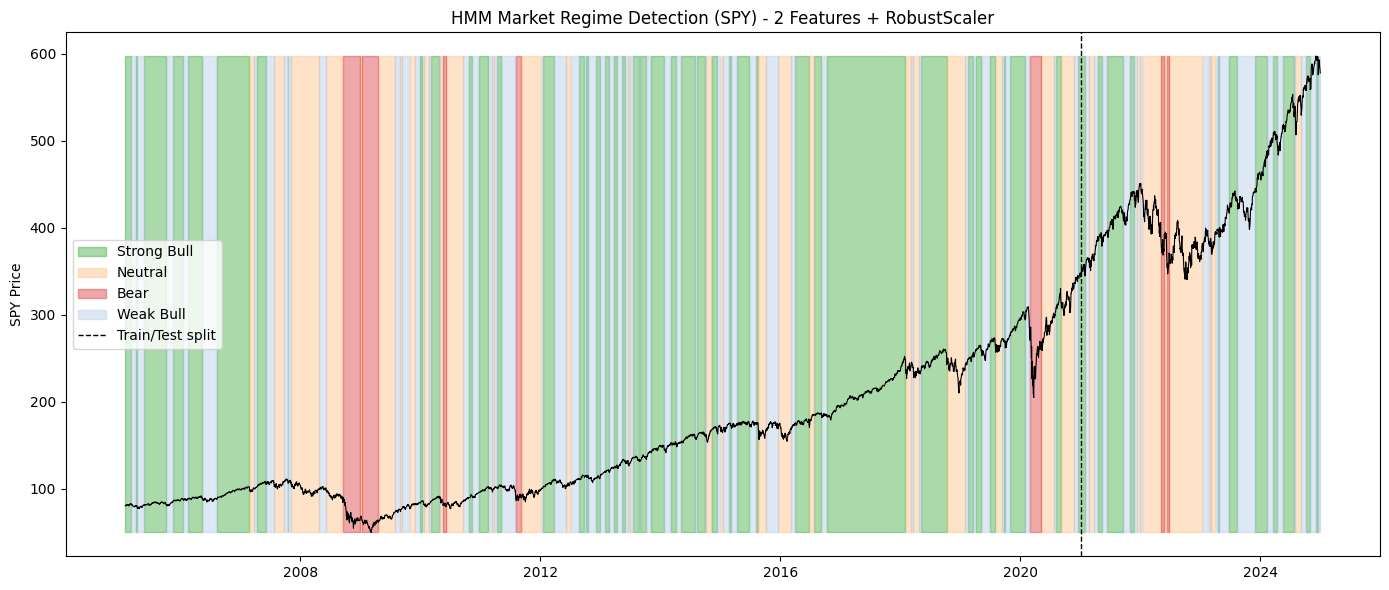

In [46]:
plt.figure(figsize=(14, 6))

plt.plot(features.index, close.loc[features.index], color='black', linewidth=0.8, zorder=3)

for state in range(4):
    mask = (states == state)
    plt.fill_between(features.index,
                     close.loc[features.index].min(),
                     close.loc[features.index].max(),
                     where=mask, alpha=0.4, color=colors[state],
                     label=state_labels[state], zorder=1)

split_date = features.index[split]
plt.axvline(split_date, color='black', linestyle='--', linewidth=1, label='Train/Test split')
plt.legend()
plt.title('HMM Market Regime Detection (SPY) - 2 Features + RobustScaler')
plt.ylabel('SPY Price')
plt.tight_layout()
plt.show()

In [45]:
for state in range(4):
    regime_returns = features['returns'].values[states == state]
    print(f"{state_labels[state]:8s} | Mean: {regime_returns.mean():.4f} | Std: {regime_returns.std():.4f} | Days: {len(regime_returns)}")

Strong Bull | Mean: 0.0009 | Std: 0.0054 | Days: 1999
Neutral  | Mean: 0.0001 | Std: 0.0140 | Days: 1286
Bear     | Mean: -0.0028 | Std: 0.0348 | Days: 251
Weak Bull | Mean: 0.0005 | Std: 0.0085 | Days: 1477


In [47]:
def compute_aic_bic(model, X):
    n_samples, n_features = X.shape
    n_states = model.n_components
    
    n_params = (
        n_states ** 2 +                 # transition matrix
        n_states * n_features +         # means
        n_states * n_features ** 2      # full covariance matrices
    )
    
    # model.score() returns total log-likelihood, no need to multiply
    log_likelihood = model.score(X)
    
    aic = 2 * n_params - 2 * log_likelihood
    bic = np.log(n_samples) * n_params - 2 * log_likelihood
    
    return aic, bic

In [48]:
results = []
all_scaled = scaler.transform(features)

for n in range(2, 7):
    m = GaussianHMM(n_components=n, covariance_type="full", 
                    n_iter=200, random_state=42)
    m.fit(scaled_train)
    
    aic, bic = compute_aic_bic(m, all_scaled)
    results.append((n, m.score(all_scaled), aic, bic, m.monitor_.converged))
    print(f"n={n} | Log-lik: {m.score(all_scaled):.2f} | AIC: {aic:.2f} | BIC: {bic:.2f} | Converged: {m.monitor_.converged}")

best_n = results[np.argmin([r[3] for r in results])][0]
print(f"\nBest number of states by BIC: {best_n}")

n=2 | Log-lik: -17273.12 | AIC: 34602.23 | BIC: 34784.79 | Converged: True
n=3 | Log-lik: -14670.89 | AIC: 29431.79 | BIC: 29725.18 | Converged: True
n=4 | Log-lik: -13194.55 | AIC: 26517.10 | BIC: 26934.37 | Converged: True
n=5 | Log-lik: -13113.30 | AIC: 26396.60 | BIC: 26950.78 | Converged: True
n=6 | Log-lik: -12004.02 | AIC: 24224.04 | BIC: 24928.17 | Converged: True

Best number of states by BIC: 6


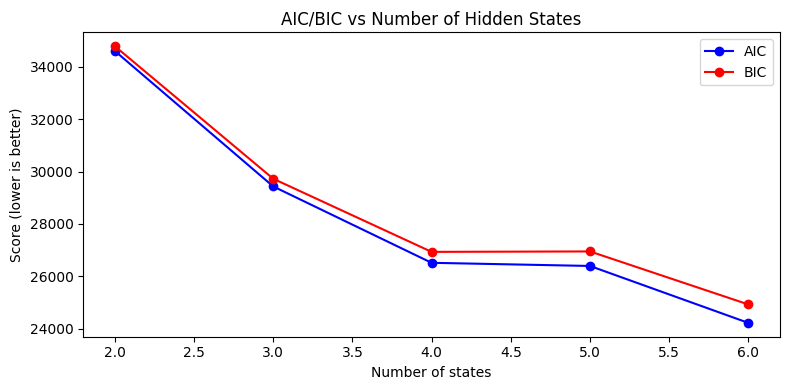

In [ ]:
ns = [r[0] for r in results]
aics = [r[2] for r in results]
bics = [r[3] for r in results]

plt.figure(figsize=(8, 4))
plt.plot(ns, aics, 'o-', label='AIC', color='blue')
plt.plot(ns, bics, 'o-', label='BIC', color='red')
plt.xlabel('Number of states')
plt.ylabel('Score (lower is better)')
plt.title('AIC/BIC vs Number of Hidden States')
plt.legend()
plt.tight_layout()
plt.show()